In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
SCORED_FILE = "../logs/classification/test_scored_gen1.parquet"

df = pd.read_parquet( SCORED_FILE )

print(df.shape)
df.head()

(147236, 121)


,date,ticker,price,beta_1y,alpha_1y,sector,quote_type,log_market_cap,pe,future_ret_1d,...,risk_adjusted_5y,sector_is_strong,sector_is_trending,sector_high_breadth,quality_score,beats_market_5y,logreg_probability,logreg_prediction,rf_probability,rf_prediction
0,2020-07-06,EGHT,15.98,1.640449,-0.033117,Technology,EQUITY,21.541141,1480.114852,-0.000626,...,0.076579,True,False,False,0,0,0.331555,0,0.340725,0
1,2020-07-13,EGHT,15.52,1.631050,-0.034542,Technology,EQUITY,21.511933,1437.508375,0.008376,...,0.101426,True,False,False,0,0,0.319037,0,0.335861,0
2,2020-07-20,EGHT,16.93,1.625617,0.054172,Technology,EQUITY,21.598891,1568.106734,-0.014176,...,0.117621,True,False,True,0,0,0.359690,0,0.346215,0
3,2020-07-27,EGHT,16.42,1.624197,0.016425,Technology,EQUITY,21.568304,1520.869003,0.007917,...,0.104128,True,False,False,0,0,0.331006,0,0.337873,0
4,2020-08-03,EGHT,16.25,1.629430,0.013561,Technology,EQUITY,21.557896,1505.123093,0.009231,...,0.080650,True,False,True,0,0,0.345362,0,0.342717,0


In [7]:
print( "Min Date:", df["date"].min())
print("Max Date:",df["date"].max())

print( "Unique Tickers:", df["ticker"].nunique())

Min Date: 2020-07-06 00:00:00
Max Date: 2021-07-01 00:00:00
Unique Tickers: 2926


In [8]:
TOP_N = 10

def select_portfolio(group):
    return (
        group
        .nlargest(TOP_N, "rf_probability")
    )

In [17]:
portfolio = (
    df.sort_values(
        ["date", "rf_probability"],
        ascending=[True, False]
    )
    .groupby("date")
    .head(TOP_N)
)

portfolio.head()

,date,ticker,price,beta_1y,alpha_1y,sector,quote_type,log_market_cap,pe,future_ret_1d,...,risk_adjusted_5y,sector_is_strong,sector_is_trending,sector_high_breadth,quality_score,beats_market_5y,logreg_probability,logreg_prediction,rf_probability,rf_prediction
115300,2020-07-06,MKSI,111.151100,1.794942,0.010785,Technology,EQUITY,22.739182,21.972115,-0.032128,...,0.785387,True,False,False,3,0,0.357134,0,0.467851,0
92337,2020-07-06,AVGO,28.075953,1.615283,0.001960,Technology,EQUITY,25.617918,5.077504,-0.017786,...,0.579143,True,False,False,3,1,0.352905,0,0.460608,0
38121,2020-07-06,AMAT,60.241611,1.729459,0.031159,Technology,EQUITY,24.590906,5.354276,-0.020170,...,0.908165,True,False,False,3,1,0.354921,0,0.456200,0
84448,2020-07-06,FICO,416.850006,1.766286,-0.013949,Technology,EQUITY,22.991997,12.458078,-0.016913,...,1.306724,True,False,False,3,1,0.381020,0,0.454755,0
77692,2020-07-06,KLAC,19.084976,1.631847,0.027378,Technology,EQUITY,23.939347,4.974626,-0.004421,...,1.185625,True,False,False,3,1,0.350392,0,0.453493,0


In [18]:
portfolio.groupby("date").size().describe()

count    51.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
dtype: float64

In [26]:
portfolio[
    [
        "date",
        "ticker",
        "rf_probability",
        "future_excess_5y",
        "future_ret_5y",
    ]
].head(50)

,date,ticker,rf_probability,future_excess_5y,future_ret_5y
115300,2020-07-06,MKSI,0.467851,-1.165490,-0.063772
92337,2020-07-06,AVGO,0.460608,7.441566,8.543283
38121,2020-07-06,AMAT,0.456200,1.029445,2.131162
84448,2020-07-06,FICO,0.454755,2.319010,3.420727
77692,2020-07-06,KLAC,0.453493,2.693685,3.795402
29254,2020-07-06,ADI,0.452195,0.066906,1.168624
65161,2020-07-06,EPAM,0.440864,-1.392594,-0.290877
72470,2020-07-06,ADSK,0.440557,-0.831706,0.270011
104569,2020-07-06,CRM,0.439191,-0.728214,0.373503
128403,2020-07-06,FIS,0.439081,-1.446168,-0.344451


In [20]:
portfolio["ticker"].value_counts().head(50)

ticker
AVGO     31
TXN      24
ACN      23
KLAC     19
ADI      18
DIOD     18
CP       17
FIS      15
MSI      15
TMTNF    14
FICO     13
SMTC     13
BR       13
STM      12
TDY      11
UNP      11
TRI      11
WOLTF    10
ITOCF    10
GRMN     10
MKSI      9
BMI       9
AME       9
DOV       9
SPXSF     9
LRCX      7
DSGX      7
GGG       7
AMAT      6
TYL       6
AAON      6
J         6
ESE       5
RTO       5
FAST      5
IEX       5
A         5
MTD       5
CIEN      5
ADSK      4
ENTG      4
MLAB      4
MSA       4
HNRG      4
TT        4
FSS       4
CRM       3
MPWR      3
SONY      3
BAH       3
Name: count, dtype: int64

In [21]:
portfolio_return = (
    portfolio
    .groupby("date")
    ["future_excess_5y"]
    .mean()
)

portfolio_return.describe()

count    51.000000
mean      0.327732
std       0.543853
min      -0.830952
25%      -0.018991
50%       0.375418
75%       0.671535
max       1.501567
Name: future_excess_5y, dtype: float64

In [28]:
random_portfolio = (
    df.groupby("date")
      .sample(
          n=TOP_N,
          random_state=42
      )
)

random_return = (
    random_portfolio
    .groupby("date")["future_excess_5y"]
    .mean()
)

print(
    "Model average:",
    portfolio_return.mean()
)

print(
    "Random average:",
    random_return.mean()
)

Model average: 0.3277319563495372
Random average: -0.04292448413237048


In [29]:
print("Model median:", portfolio_return.median())
print("Random median:", random_return.median())

Model median: 0.3754178525899951
Random median: -0.24540192683856468


In [23]:
model_win_rate = (
    portfolio
    .groupby("date")
    ["beats_market_5y"]
    .mean()
)

print(
    "Model beat-market rate:",
    model_win_rate.mean()
)

Model beat-market rate: 0.3333333333333333


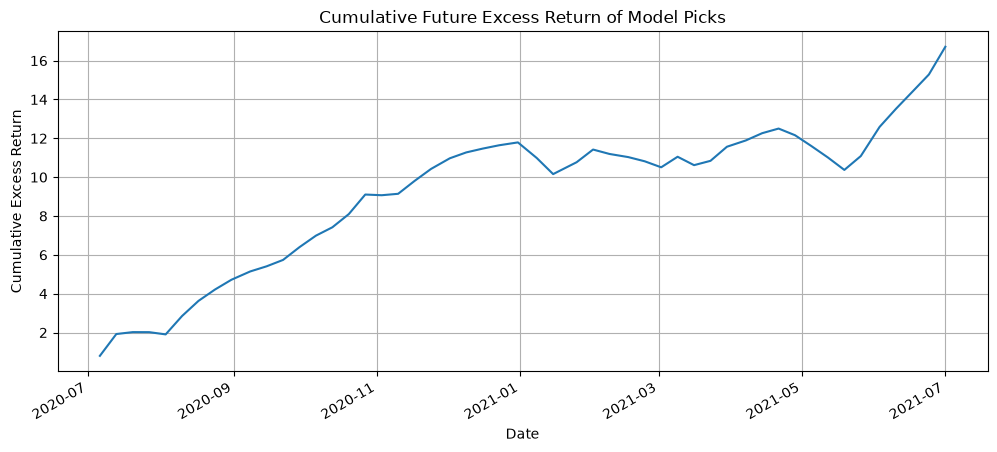

In [24]:
plt.figure(figsize=(12,5))

portfolio_return.sort_index().cumsum().plot()

plt.title(
    "Cumulative Future Excess Return of Model Picks"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Excess Return")

plt.grid()
plt.show()

In [25]:
stock_summary = (
    portfolio.groupby("ticker")
    .agg(
        selections=("ticker","count"),
        avg_probability=("rf_probability","mean"),
        avg_return=("future_excess_5y","mean"),
        beat_rate=("beats_market_5y","mean")
    )
    .sort_values(
        ["selections","beat_rate"],
        ascending=False
    )
)

stock_summary.head(50)

,selections,avg_probability,avg_return,beat_rate
ticker,,,,
AVGO,31,0.463374,7.782043,1.000000
TXN,24,0.446163,-0.410822,0.083333
ACN,23,0.445970,-1.012741,0.000000
KLAC,19,0.467379,3.033359,1.000000
ADI,18,0.459058,0.176064,0.833333
DIOD,18,0.474531,-1.200443,0.000000
CP,17,0.431363,-0.742496,0.000000
MSI,15,0.451964,0.448461,1.000000
FIS,15,0.458876,-1.524785,0.000000
